# Ch10-2 트랜스포머로 상품 설명 요약하기

트랜스포머 모델은 인코더와 디코더를 각각 떼어 독립적으로 사용 가능

## 1. 트렌스포머 가계도



## 2. 전이학습 Transfer learning


## 3. BART 모델 
메타에서 공개한 트랜스포머 기반의 인코더-디코더 언어모델
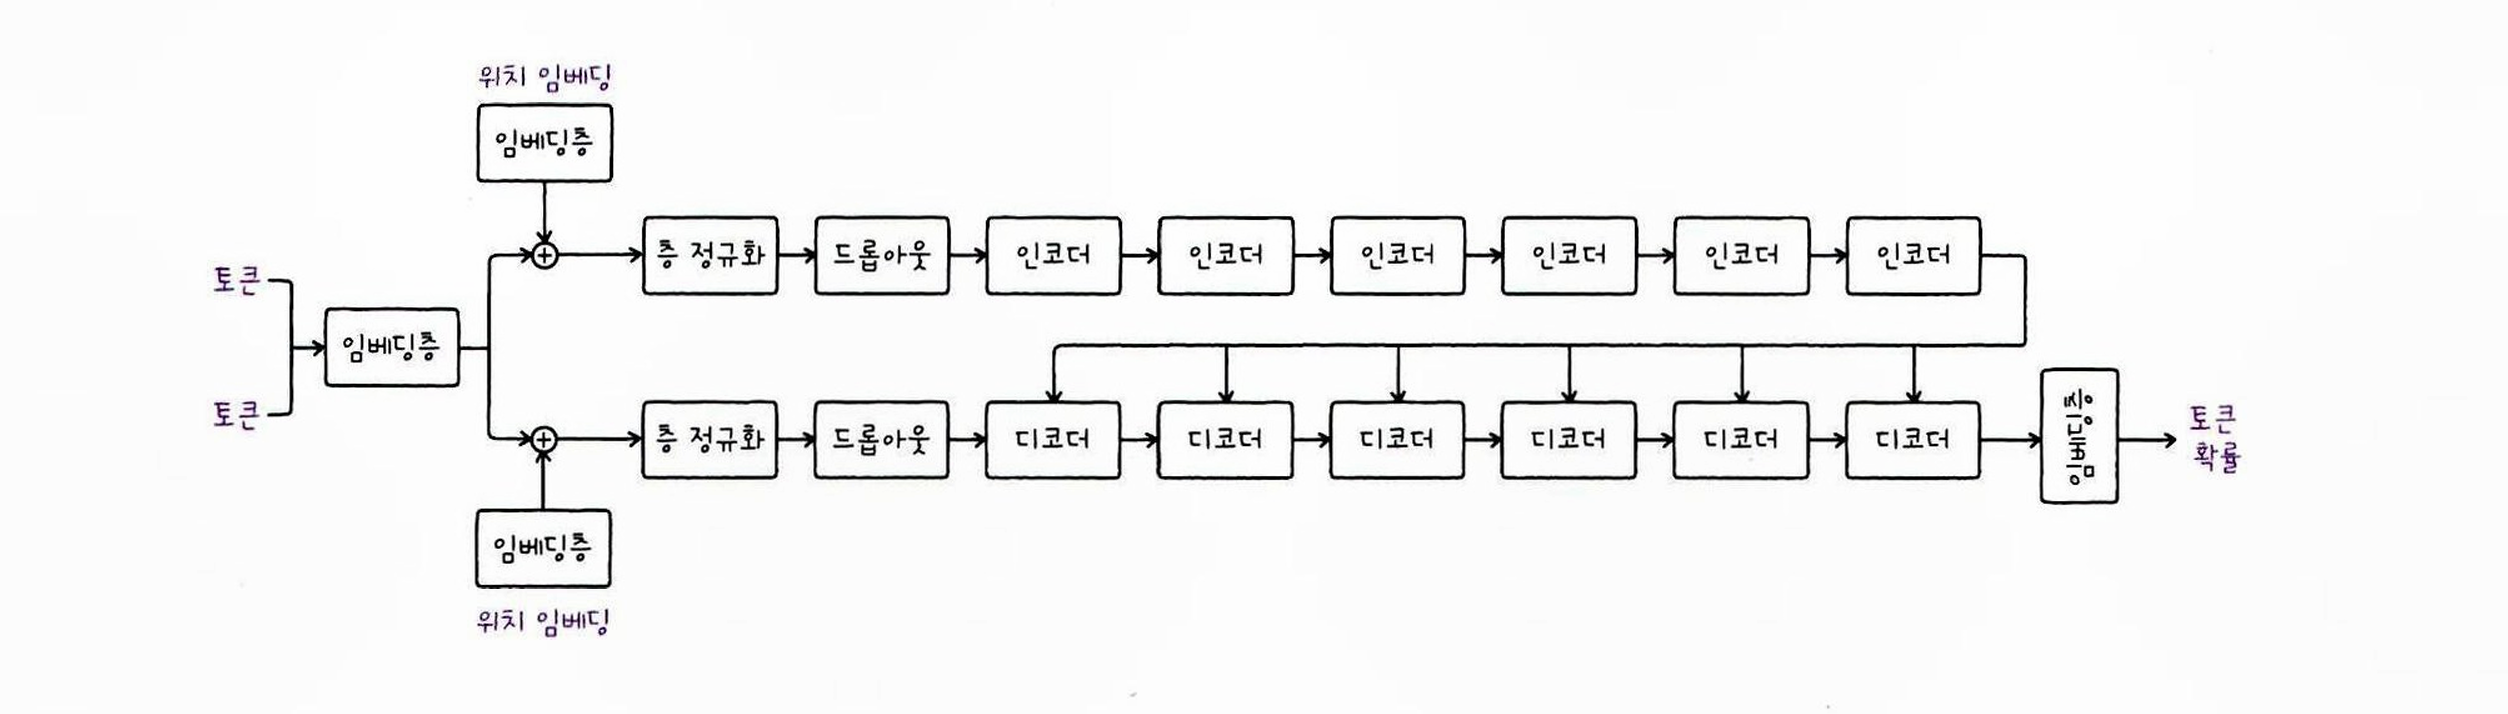

## 4. BART 의 인코더, 디코더
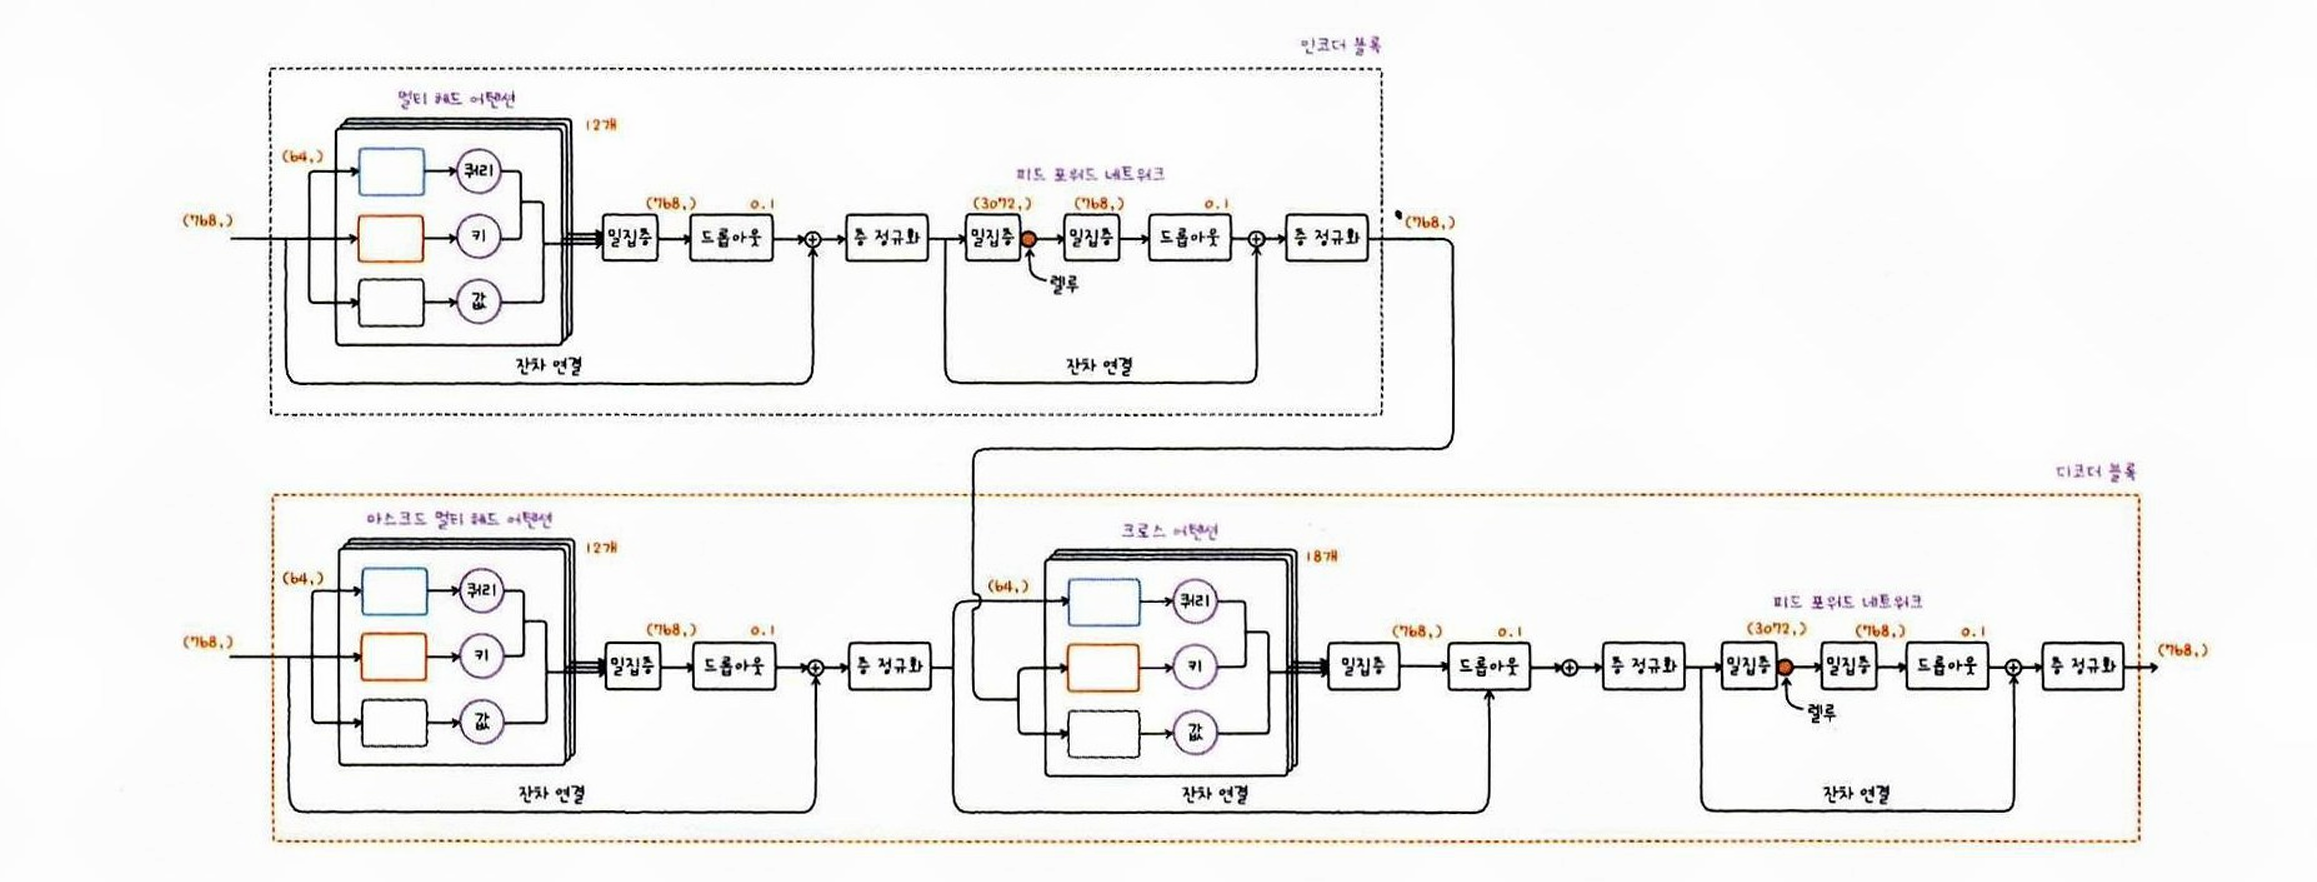

활성화 함수 로 렐루 대신 젤루 GeLU를 사용       

1. (768,) 크기의 임베딩 벡터가 인코더 블록에 입력되면, 12개의 헤드에 나누어 전달
2.  헤드에 입력되는 벡터 크기는 (64,)
3. 멀티 헤드 어텐션의 마지막 밀집층을 통과하면서 다시 (768,) 크기의 벡터로 변환
4. BART는 인코더와 디코더에 드롭아웃 비율이 0.1 인 드롭아웃 층을 사용
5. 드롭아웃 층을 지난 후 잔차 연결이 나오고 층 정규화
6.  그다음 피드포워드 네트워크
7. 피드포워드의 첫 번째 밀집층은 임베딩 벡터 차원의 네 배인(3072,)의 출력을 만듦
8.  두 번째 밀집층은 다시 원래 임베딩 차원인 (768, )의 출력을 만듦

# 5. 허깅페이스로 KoBART 모델 로드하기

In [1]:
from transformers import pipeline

pipe = pipeline(task='summarization', device=0)


2025-12-10 10:50:40.732333: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-10 10:50:41.608586: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-10 10:50:45.033269: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (htt

In [2]:
from transformers import pipeline

pipe = pipeline(task='summarization', model='sshleifer/distilbart-cnn-12-6', device=0)


Device set to use cuda:0


In [3]:
sample_text = """Vincent Willem van Gogh was a Dutch Post-Impressionist
painter who is among the most famous and influential figures in the history
of Western art. In just over a decade, he created approximately 2100
artworks, including around 860 oil paintings, most of them in the last two
years of his life. His oeuvre includes landscapes, still lifes, portraits,
and self-portraits, most of which are characterised by bold colours and
dramatic brushwork that contributed to the rise of expressionism in modern
art. Van Gogh's work was beginning to gain critical attention before he died
from a self-inflicted gunshot at age 37. During his lifetime, only one of
Van Gogh's paintings, The Red Vineyard, was sold.
"""
pipe(sample_text)

[{'summary_text': " Vincent Willem van Gogh was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art . His oeuvre includes landscapes, still lifes, portraits, and self-portraits . Van Gogh's work was beginning to gain critical attention before he died from a gunshot wound at age 37 ."}]

출력 = 딕셔너리의 리스트        
bart는 영어만 가능해서, 한글 데이터셋 미세튜닝한 다른 모델로 적용

In [4]:
kobart = pipeline(task='summarization',
                    model = 'EbanLee/kobart-summary-v3', device=0)

config.json: 0.00B [00:00, ?B/s]

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/692 [00:00<?, ?B/s]

Device set to use cuda:0


In [5]:
ko_text = """하나, ‘입문자 맞춤형 7단계 구성’을 따라가며 체계적으로 반복하는 탄탄한 학습 설계!
이 책은 데이터 분석의 핵심 내용을 7단계에 걸쳐 반복 학습하면서 자연스럽게 머릿속에 기억되도록 구성했습니다. [핵심 키워드]와 [시작하기 전에]에서 각 절의 주제에 대한 대표 개념을 워밍업하고, 이론과 실습을 거쳐 마무리에서는 [핵심 포인트]와 [확인 문제]로 한번에 복습합니다. ‘혼자 공부할 수 있는’ 커리큘럼을 그대로 믿고 끝까지 따라가다 보면 데이터 분석 공부가 난생 처음인 입문자도 무리 없이 책을 끝까지 마칠 수 있습니다!
둘, 실제로 일어날 법한 흥미로운 스토리에 담긴 문제를 직접 해결하며 익히는 ‘진짜’ 데이터 분석!
현장감 넘치는 스토리를 통해 데이터를 다루는 방법을 알려 주어 ‘파이썬’과 ‘데이터’가 낯설어도 몰입감 있는 학습을 할 수 있도록 구성했습니다. 이 책에서는 API와 웹 스크래핑을 통해 실제 도서관 데이터와 온라인 서점 웹사이트에서 데이터를 가져오는 등 내 주변에 있는 데이터를 직접 수집할 수 있는 방법을 가이드합니다. 또한 판다스, 넘파이, 맷플롯립 등 데이터 분석에 유용한 각종 파이썬 라이브러리를 활용해 보며 코딩 감각을 익히고, 핵심 통계 지식으로 기본기를 탄탄하게 다질 수 있습니다. 마지막에는 분석을 바탕으로 미래를 예측하는 머신러닝까지 맛볼 수 있어 데이터 분석의 처음부터 끝까지 제대로 배울 수 있습니다.
셋, ‘혼공’의 힘을 실어줄 동영상 강의와 혼공 학습 사이트 지원!
책으로만 학습하기엔 여전히 어려운 입문자를 위해 저자 직강 동영상도 지원합니다. 또한 학습을 하며 궁금한 사항은 언제든지 저자에게 질문할 수 있도록 학습 사이트를 제공합니다. 저자가 질문 하나하나에 직접 답변을 달아 주는 것은 물론, 관련 최신 기술과 정보도 얻을 수 있습니다. 게다가 혼자 공부하고 싶지만 정작 혼자서는 자신 없는 사람들을 위해 혼공 학습단을 운영합니다. 혼공 학습단과 함께하면 마지막까지 포기하지 않고 완주할 수 있을 것입니다.
▶ https://hongong.hanbit.co.kr
▶ https://github.com/rickiepark/hg-da
넷, 언제 어디서든 가볍게 볼 수 있는 혼공 필수 [용어 노트] 제공!
꼭 기억해야 할 핵심 개념과 용어만 따로 정리한 [용어 노트]를 제공합니다. 처음 공부하는 사람들이 프로그래밍을 어려워하는 이유는 낯선 용어 때문입니다. 그러나 어려운 것이 아니라 익숙하지 않아서 헷갈리는 것이므로, 용어나 개념이 잘 생각나지 않을 때는 언제든 부담 없이 [용어 노트]를 펼쳐 보세요. 제시된 용어 외에도 새로운 용어를 추가하면서 자신만의 용어 노트를 완성해가는 과정도 또 다른 재미가 될 것입니다.
"""

In [7]:
kobart(ko_text)

[{'summary_text': '이 책은 데이터 분석의 핵심 내용을 7단계에 걸쳐 반복 학습하면서 머릿속에 기억되도록 구성했습니다. 독자 공부할 수 있는 커리큘럼을 그대로 믿고 끝까지 따라가다 보면 데이터 분석 공부가 난생 처음인 입문자도 무리 없이 책을 끝까지 마칠 수 있습니다. 현장감 넘치는 스토리를 통해 데이터를 다루는 방법을 알려 주어 몰입감 있는 학습을 할 수 있도록 구성했습니다. 저자가 질문 하나하나에 직접 답변을 달아 주는 것은 물론, 최신 기술과 정보도 얻을 수 있습니다. 혼공 학습단과 함께하면 마지막까지 포기하지 않고 완주할 수 있을 것입니다. 꼭 기억해야 할 핵심 개념과 용어만 따로 정리한 [용어 노트]를 제공합니다. 새로운 용어를 추가하면서 자신만의 용어 노트를 완성해가는 과정도 재미가 될 것입니다.'}]

beam search라는 방법을 사용하므로 실행할 때마다 결과가 다를 수 있다.

In [8]:
print(kobart.model.config)

BartConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_bias_logits": false,
  "add_final_layer_norm": false,
  "architectures": [
    "BartForConditionalGeneration"
  ],
  "attention_dropout": 0.0,
  "author": "EbanLee(rudwo6769@gmail.com)",
  "bos_token_id": 1,
  "classif_dropout": 0.1,
  "classifier_dropout": 0.1,
  "d_model": 768,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 3072,
  "decoder_layerdrop": 0.0,
  "decoder_layers": 6,
  "decoder_start_token_id": 1,
  "do_blenderbot_90_layernorm": false,
  "dropout": 0.1,
  "dtype": "float32",
  "encoder_attention_heads": 16,
  "encoder_ffn_dim": 3072,
  "encoder_layerdrop": 0.0,
  "encoder_layers": 6,
  "eos_token_id": 1,
  "extra_pos_embeddings": 2,
  "force_bos_token_to_be_generated": false,
  "forced_eos_token_id": 1,
  "gradient_checkpointing": false,
  "id2label": {
    "0": "NEGATIVE",
    "1": "POSITIVE"
  },
  "init_std": 0.02,
  "is_encoder_decoder": true,
  "kobart_version": 2.0,
  "label2id

In [9]:
kobart.model

BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(30000, 768, padding_idx=3)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(30000, 768, padding_idx=3)
      (embed_positions): BartLearnedPositionalEmbedding(1028, 768)
      (layers): ModuleList(
        (0-5): 6 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (final_layer_n

# 6. 텍스트 토큰화

토큰화를 수행하는 모델 **토크나이저_tokenizer** 라고 부른다. 
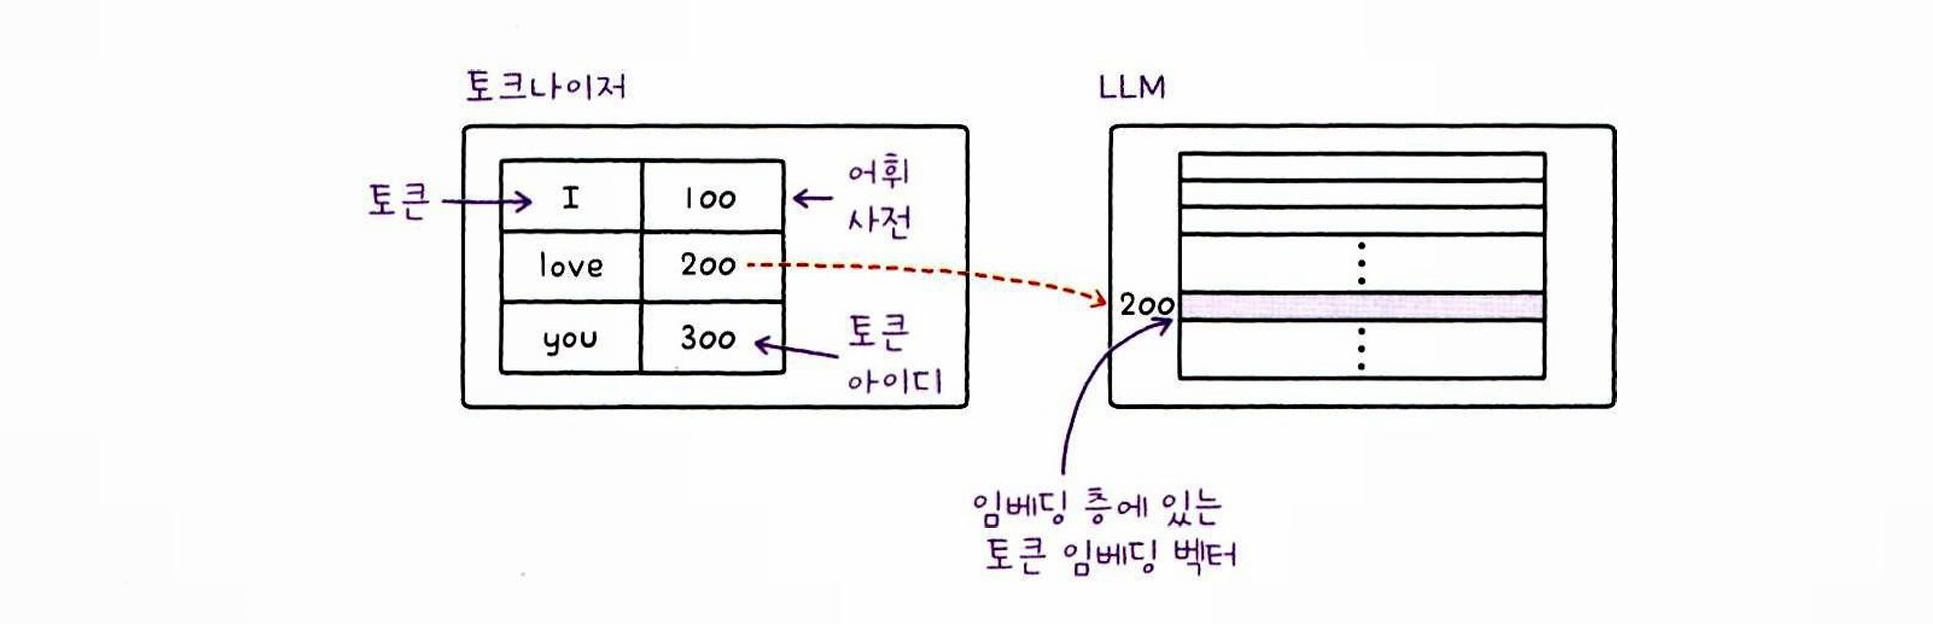

**종류**
- BPE Byte Pair Encoding
- WordPiece
- Unigram
- SentencePiece

토큰화 방법
### BPE Byte Pair Encoding
BPE 는 각 단어를 문자 단위로 분해 -> 어휘사전에 추가 -> 가장 많이 등장하는 순서대로 문자 쌍을 찾아 병합 -> 합쳐진 부분 단어를 어휘 사전에 추가 -> 사전에 정의된 어휘사전 크기에 도달할 때까지 계속 진행

그러나 단점으로 유니코드 문자를 처리할 때, 어휘사전의 크기가 매우 커지게 됨.        

따라서, 발전하여 등장한 것이    
**바이트 수준의 BPE_ Byte Level BPE**
- 적절한 수준의 어휘 사전 크기에서 유니코드를 처리        
- 텍스트를 바이트 스트림으로 인식하고, 자주 등장하는 바이트 쌍을 어휘 사전에 추가하는 방식.     
- 

In [ ]:
print(kobart.tokenizer.vocab_size) #어휘 사전 크기

30000


In [11]:
len(kobart.tokenizer)

30000

In [12]:
vocab = kobart.tokenizer.vocab
len(vocab)

30000

In [ ]:
list(vocab.items())[:10] #튜플 리스트 출력

[('들에게는', 21150),
 ('▁마련됐다.\n', 25436),
 ('옂', 11822),
 ('悼', 3937),
 ('뀰', 9462),
 ('▁경찰이', 19183),
 ('跃', 7779),
 ('碉', 6084),
 ('Ц', 717),
 ('娩', 3314)]

In [14]:
tokens = kobart.tokenizer.tokenize('혼자 만들면서 공부하는 딥러닝')
print(tokens)

['▁혼자', '▁만들', '면서', '▁공부', '하는', '▁', '딥', '러', '닝']


In [15]:
#토큰 아이디 찾기
kobart.tokenizer.convert_tokens_to_ids(tokens)

[16814, 14397, 14125, 16962, 14049, 1700, 10021, 10277, 9747]

In [16]:
token_ids = kobart.tokenizer.encode('혼자 만들면서 공부하는 딥러닝')
print(token_ids)

[0, 16814, 14397, 14125, 16962, 14049, 1700, 10021, 10277, 9747, 1]


0 = 시작 1 = 끝

In [17]:
#토큰 아이디를 토큰으로 변경
tokens = kobart.tokenizer.convert_ids_to_tokens(token_ids)
print(tokens)

['<s>', '▁혼자', '▁만들', '면서', '▁공부', '하는', '▁', '딥', '러', '닝', '</s>']


In [18]:
# 문자열로 복원
kobart.tokenizer.decode(token_ids)

'<s> 혼자 만들면서 공부하는 딥러닝</s>'

토큰화 방법
### WordPiece
BPE 토큰화와 매우 비슷.     
- 훈련 데이터셋에 있는 모든 문자가 포함된 어휘사전으로 시작     
- 가장 많이 등장하는 부분단어 쌍을 어휘 사전에 추가         

--> + 부분단어를 구성하는 개별 토큰의 빈도도 고려   

예를 들어 “ab” 토큰과 “cd” 토큰의 빈도가 각각 10과 20이라면         
- BPE 알고리즘은 “cd” 토큰을 먼저 어휘 사전에 추가      
- 하지만 워드피스는 “ab” 토큰의 빈도를 “a”와 “b” 토큰의 빈도로 나누고, 마찬가지로 “cd” 토큰의 빈도를 “c”와 “d” 토큰의 빈도로 나누어 둘 중 큰 값을 가진 토큰을 어휘사전에 추가       

### Unigram
- 초기에 매우 큰 어휘 사전을 만든 다음 사전에 지정한 어휘 사전 크기에 도달할 때까지 점진적으로 토큰을 제거
- 초기 어휘 사전은 공백으로 나누어진 단어를 부분단어로 쪼개어 추가하거나 BPE 알고리즘을 적용하여 만듦    

- 모든 토큰이 독립적이라고 가정하고, 전체 손실을 가장 적게 증가시키는 토큰을 하나씩 삭제.    
(손실 = 각 토큰의 등장 확률을 곱한 것에 음수를 곱한 값)     



### SentencePiece
지금까지의 토큰화 방법은 먼저 텍스트를 공백 등의 기준으로 단어를 나누었음 (사전 토큰화 pre-tokennization)
하지만 중국어 같은 경우 이런 방식이 통하지 않음. 
따라서, 센텐스 피스는 원시 입력 텍스트를 그대로 사용하여, 공백을 하나의 문자로 간주.        


In [ ]:
토큰화 방법
### 